# Trabajo de datos

Este archivo contiene los scripts y procedimientos utilizados para la recopilación, limpieza y análisis de datos del proyecto de predicción de TPV para PSPs. A continuación se describen las diferentes secciones y su propósito. Cualquier tipo de trabajo adicional o modificaciones deben ser realizadas y documentadas en este notebook.

La segmentación en archivos separados de tipo .py se hará futuramente para mejorar la organización, import de archivos, creación de entorno virtual y facilitar el mantenimiento del código, sumado a la implementación sencilla en plataformas como streamlit.

Supuestos de la data actual: Se toma data desde 2023-01-01 hasta 2025-12-31. El objetivo es maximizar la cantidad de datos disponibles para el entrenamiento. Las variables a partir de fechas anteriores consideran hasta un máximo de un año, por lo tanto esta data permite trabajar con un conjunto de variables de hasta dos años de antigüedad (2024 y 2025).

## Import de librerías y datos

### Librerías

In [51]:
# Librerías a utilizar
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

### Datos iniciales

In [52]:
# Ajusta la ruta
ruta_data = os.path.join('..', 'data', 'base_proyecto_ml_v2.parquet')

try:
    df = pd.read_parquet(ruta_data)
except FileNotFoundError:
    print(f"El archivo no existe en la ruta: {ruta_data}")
    df = None
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")
    df = None

# Data original posee columnas que no se utilizarán en el modelo
df.drop(columns=['id_sucursal', 'fecha_devolucion', 'tipo_tx', 'merchant_neto'], inplace=True, errors='ignore')

### Verificación de datos iniciales

In [53]:
# Mostrar las primeras filas del DataFrame si se cargó correctamente
df.head() if df is not None else None

,id_comercio,fecha_trx,marca_liq,mcc,nacionalidad,categoria_producto,tarjeta_presente,cantidad_tx,tpv
0,76923783-6,2022-01-01,VISA,4899.0,Nacional,PREPAGO,No,2433,14778271.0
1,76923783-6,2022-01-01,MASTERCARD,7311.0,Nacional,CREDITO,No,5742,33185381.0
2,76237019-0,2022-01-01,VISA,4121.0,Nacional,PREPAGO,No,969,10572178.0
3,76923783-6,2022-01-01,VISA,7311.0,Internacional,DEBITO,No,2535,3637964.0
4,76923783-6,2022-01-01,MASTERCARD,5816.0,Nacional,CREDITO,No,2243,25515103.0


In [54]:
# Mostrar información del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4859217 entries, 0 to 4859216
Data columns (total 9 columns):
 #   Column              Dtype  
---  ------              -----  
 0   id_comercio         object 
 1   fecha_trx           object 
 2   marca_liq           object 
 3   mcc                 float64
 4   nacionalidad        object 
 5   categoria_producto  object 
 6   tarjeta_presente    object 
 7   cantidad_tx         int64  
 8   tpv                 float64
dtypes: float64(2), int64(1), object(6)
memory usage: 333.7+ MB


## Análisis y limpieza de datos iniciales

In [55]:
# Verificar valores nulos en el DataFrame
df.isnull().sum()
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Eliminar filas con valores nulos
df.dropna(inplace=True)


Valores nulos por columna:
id_comercio             0
fecha_trx               0
marca_liq               0
mcc                   220
nacionalidad          220
categoria_producto      0
tarjeta_presente      220
cantidad_tx             0
tpv                   220
dtype: int64


### id_comercio

In [56]:
# Obtener los valores únicos de id_comercio
print(f"Cantidad de comercios: {len(df['id_comercio'].unique())}")

Cantidad de comercios: 23


In [57]:
# Mapeo a nombres de comercios
mapping_comercio = {
    '76516950-K': 'MERCPAGO',
    '76795561-8': 'HAULMER SPA',
    '76923783-6': 'DLOCAL',
    '99584660-8': 'PAYU',
    '76389778-8': 'EBANX CHILE S.A.',
    '76400485-K': 'FUDO',
    '77126383-6': 'TOKU SPA',
    '76211425-9': 'PEDIDOS YA',
    '76772379-2': 'PPRO',
    '77401986-3': 'PAGSEGURO',
    '77005329-3': 'NUVEI CHILE SPA',
    '77784488-1': 'PAYSCAN SPA',
    '77367796-4': 'INDRIVE',
    '76237019-0': 'CABIFY',
    '76478111-2': 'VIRTUALPOS',
    '76837223-3': 'RAPPI',
    '77101928-5': 'SUMUP CHILE PAYMENTS S.A',
    '77733347-K': 'RECIBOPAGOS SPA',
    '77427651-3': 'EBANX',
    '77125361-K': 'DELIVERY HERO STORES CHILE SPA',
    '78057888-2': 'COPEC',
    '77332933-8': 'CLPRO SPA',
    '97023000-9': 'ITAU CORPBANCA',
    '77152076-6': 'PAGSMILE',
    '76830014-3': 'FLOW S.A.',
    '76584147-K': 'PAYKU SPA'
}

# Crear la nueva columna 'nombre_comercio' usando el mapeo
# Usar .fillna() para que si el RUT no existe en el diccionario, se use el valor original de 'id_comercio'
df['nombre_comercio'] = df['id_comercio'].map(mapping_comercio).fillna(df['id_comercio'])

# Eliminar la columna original 'id_comercio'
df.drop(columns=['id_comercio'], inplace=True)

In [58]:
# Obtener distribución de filas (no transacciones ni tpv) de la columna nombre_comercio
distribucion_comercios = df['nombre_comercio'].value_counts()
print(f"\nDistribución de comercios:\n{distribucion_comercios}")


Distribución de comercios:
nombre_comercio
MERCPAGO                          3380450
DLOCAL                             535770
HAULMER SPA                        229570
PAYU                               157274
EBANX CHILE S.A.                   147949
PEDIDOS YA                         115910
TOKU SPA                            86490
SUMUP CHILE PAYMENTS S.A            71553
FUDO                                35428
NUVEI CHILE SPA                     22595
RAPPI                               18860
INDRIVE                             10693
PPRO                                10556
CABIFY                               8971
DELIVERY HERO STORES CHILE SPA       6492
EBANX                                5162
PAYSCAN SPA                          5161
PAGSEGURO                            4825
ITAU CORPBANCA                       3568
CLPRO SPA                             801
VIRTUALPOS                            563
RECIBOPAGOS SPA                       353
PAGSMILE                        

In [59]:
# Eliminar filas con comercios de pocas instancias
comercios_a_eliminar = distribucion_comercios[distribucion_comercios < 100].index
df = df[~df['nombre_comercio'].isin(comercios_a_eliminar)]


Distribución porcentual de instancias de comercios:
nombre_comercio
MERCPAGO                          69.570985
DLOCAL                            11.026356
HAULMER SPA                        4.724641
PAYU                               3.236761
EBANX CHILE S.A.                   3.044848
PEDIDOS YA                         2.385473
TOKU SPA                           1.779998
SUMUP CHILE PAYMENTS S.A           1.472589
FUDO                               0.729122
NUVEI CHILE SPA                    0.465014
RAPPI                              0.388146
INDRIVE                            0.220066
PPRO                               0.217247
CABIFY                             0.184627
DELIVERY HERO STORES CHILE SPA     0.133608
EBANX                              0.106236
PAYSCAN SPA                        0.106215
PAGSEGURO                          0.099300
ITAU CORPBANCA                     0.073431
CLPRO SPA                          0.016485
VIRTUALPOS                         0.011587
RECIBOP

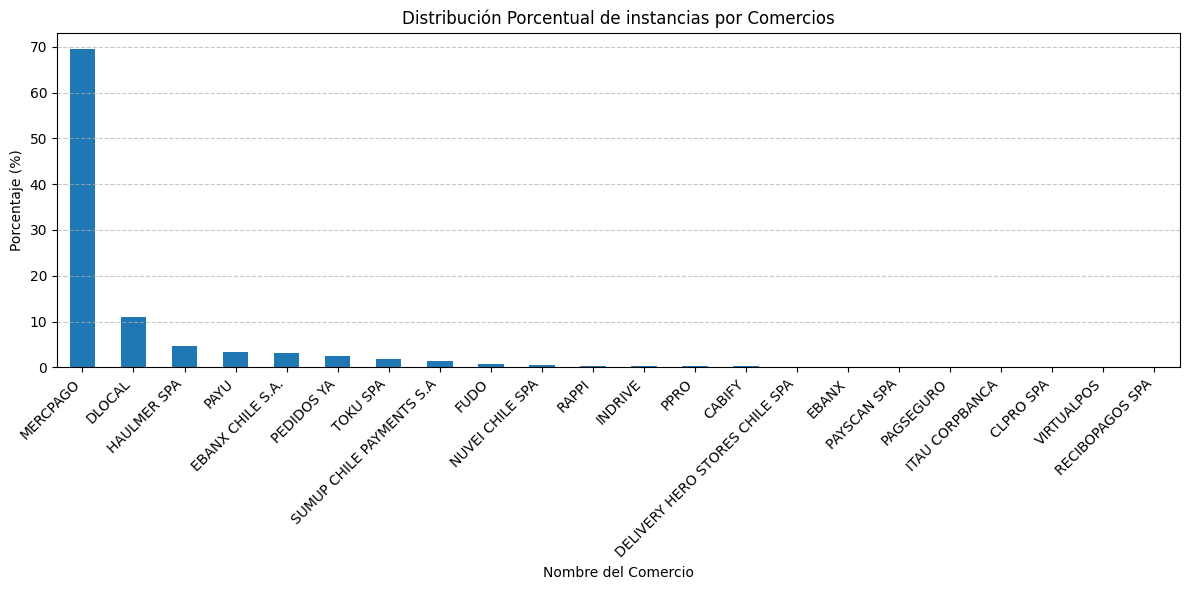

In [60]:
# Distribución porcentual después de eliminar
distribucion_comercios_post = df['nombre_comercio'].value_counts(normalize=True) * 100
print(f"\nDistribución porcentual de instancias de comercios:\n{distribucion_comercios_post}")

# Gráfico de barras de la distribución porcentual
plt.figure(figsize=(12, 6))
distribucion_comercios_post.plot(kind='bar')
plt.title('Distribución Porcentual de instancias por Comercios')
plt.xlabel('Nombre del Comercio')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




Total de Transacciones Históricas por Comercio:
                   nombre_comercio  total_tx_historico
10                        MERCPAGO           837553762
3                           DLOCAL           435636232
14                            PAYU           422050037
19        SUMUP CHILE PAYMENTS S.A           152045222
15                      PEDIDOS YA           102800973
5                 EBANX CHILE S.A.            44836693
7                      HAULMER SPA            42256282
13                     PAYSCAN SPA            39025997
0                           CABIFY            13526258
11                 NUVEI CHILE SPA             8549457
17                           RAPPI             6756993
20                        TOKU SPA             5544074
6                             FUDO             4741972
8                          INDRIVE             4535884
16                            PPRO             1296238
12                       PAGSEGURO              669863
21              

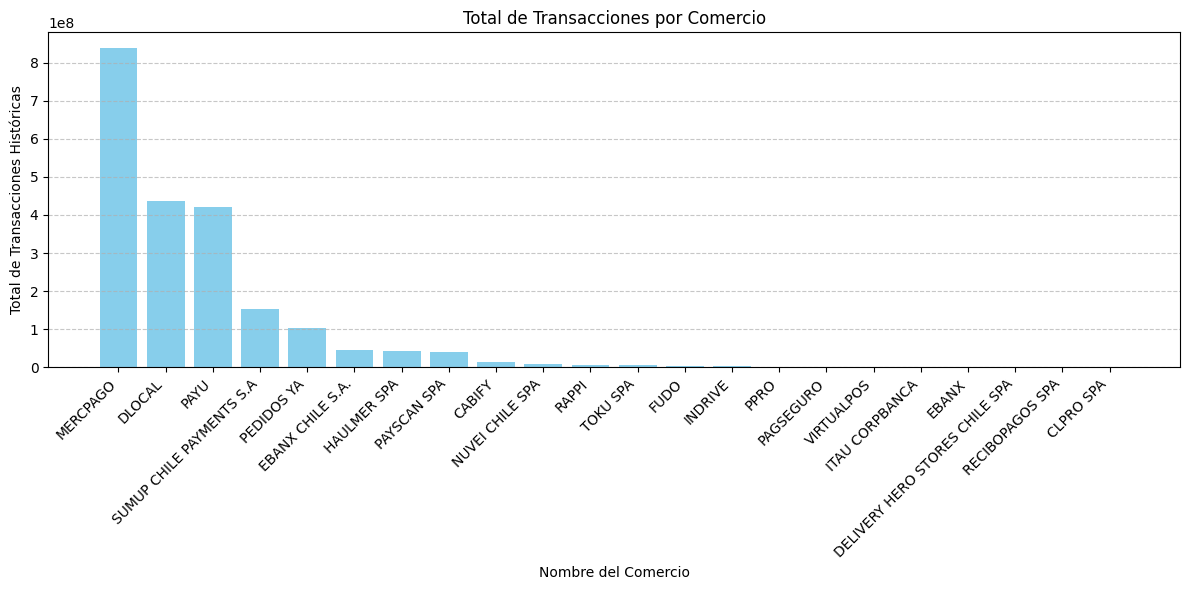

In [61]:
# Agrupamos por nombre y sumamos la columna 'cantidad_tx'
tx_por_comercio = df.groupby('nombre_comercio')['cantidad_tx'].sum().reset_index()

# Renombramos la columna para que sea descriptiva
tx_por_comercio.rename(columns={'cantidad_tx': 'total_tx_historico'}, inplace=True)

# Ordenamos de mayor a menor para ver los más transaccionales primero
tx_por_comercio = tx_por_comercio.sort_values('total_tx_historico', ascending=False)

# Mostramos el resultado
print("\nTotal de Transacciones Históricas por Comercio:")
print(tx_por_comercio)

# Visualizamos con un gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(tx_por_comercio['nombre_comercio'], tx_por_comercio['total_tx_historico'], color='skyblue')
plt.title('Total de Transacciones por Comercio')
plt.xlabel('Nombre del Comercio')
plt.ylabel('Total de Transacciones Históricas')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### fecha_trx

In [62]:
# Obtener el tipo de dato de la columna fecha_trx
print(f"Tipo de dato de la columna 'fecha_trx': {df['fecha_trx'].dtype}")

# Obtener los valores únicos de fecha_trx (solo para verificar que la cantidad de días es correcta)
print(f"Cantidad de días únicos: {len(df['fecha_trx'].unique())}")

# Convertir la columna fecha_trx a tipo datetime
df['fecha_trx'] = pd.to_datetime(df['fecha_trx'], format='%Y-%m-%d')
# Verificar el cambio de tipo de dato
print(f"Nuevo tipo de dato de la columna 'fecha_trx': {df['fecha_trx'].dtype}")

Tipo de dato de la columna 'fecha_trx': object
Cantidad de días únicos: 1461
Nuevo tipo de dato de la columna 'fecha_trx': datetime64[ns]


### marca_liq

Tipo de dato de la columna marca_liq: object
Cantidad marcas únicas: 4
['VISA' 'MASTERCARD' 'MAESTRO' 'AMEX']


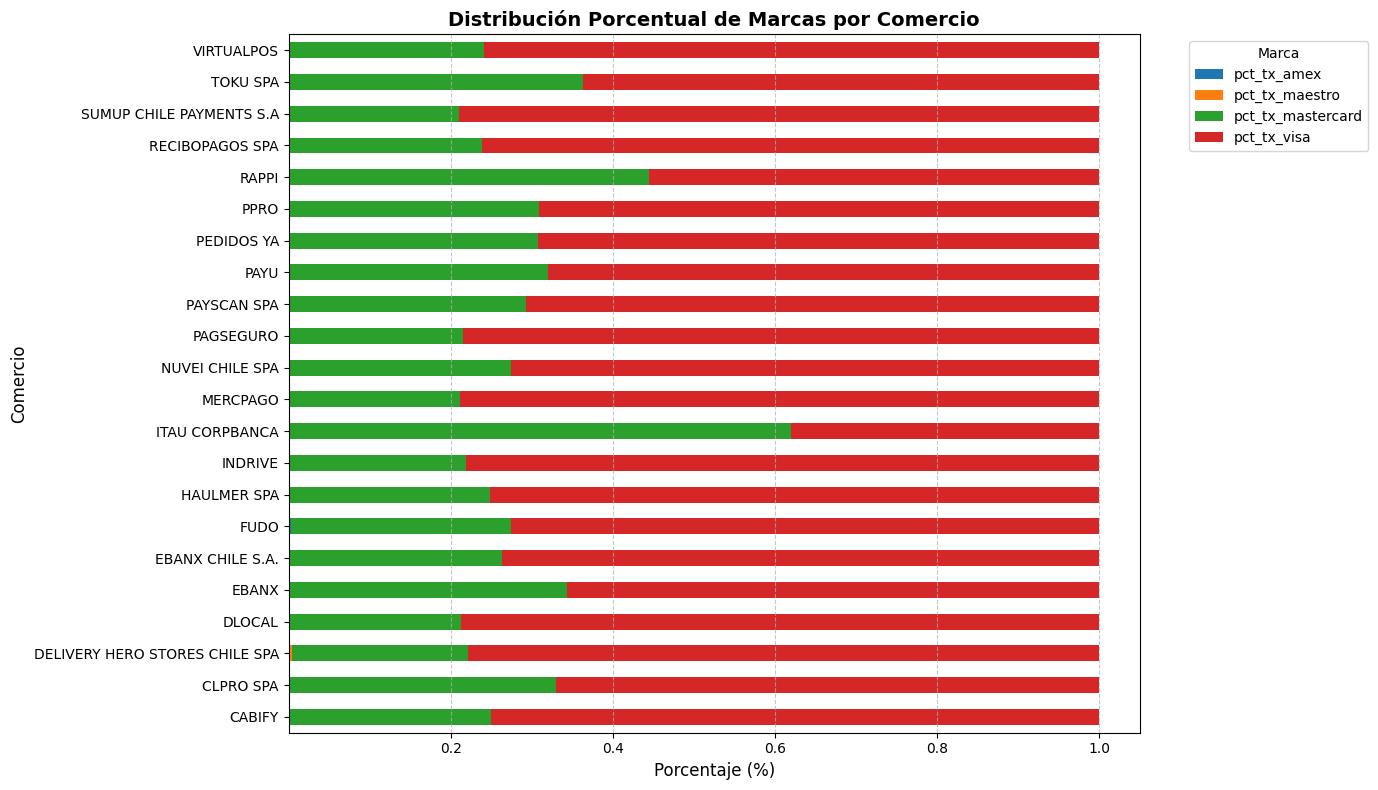

In [63]:
# Obtener el tipo de dato de la columna marca_liq
print(f"Tipo de dato de la columna marca_liq: {df['marca_liq'].dtype}")

# Obtener los valores únicos de marca_liq
print(f"Cantidad marcas únicas: {len(df['marca_liq'].unique())}")
print(f"{df['marca_liq'].unique()}")


# Distribución de la columna marca_liq por transacciones
# fill_value=0, si un comercio no tiene, pone 0 en vez de NaN.
df_mix = df.pivot_table(
    index='nombre_comercio', # Filas
    columns='marca_liq',  # Columnas
    values='cantidad_tx', # Valores a agregar
    aggfunc='sum', # Función de agregación
    fill_value=0
)

# Calcular el porcentaje
# Dividimos cada celda por la suma total de la fila (axis=0)
df_mix_pct = df_mix.div(df_mix.sum(axis=1), axis=0)

# Renombrar las columnas para que sean amigables para el modelo
# De 'VISA' pasa a 'pct_tx_VISA'
df_mix_pct.columns = [f'pct_tx_{col.lower().replace(" ", "_")}' for col in df_mix_pct.columns]

# Visualizar el resultado
fig, ax = plt.subplots(figsize=(14, 8))
df_mix_pct.plot(kind='barh', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Distribución Porcentual de Marcas por Comercio', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje (%)', fontsize=12)
ax.set_ylabel('Comercio', fontsize=12)
ax.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### mcc

In [64]:
# Obtener el tipo de dato de la columna mcc
print(f"Tipo de dato de la columna mcc: {df['mcc'].dtype}")

# Pasar de string a entero la columna mcc
df['mcc'] = pd.to_numeric(df['mcc'], errors='coerce').fillna(0).astype(int)
print(f"Nuevo tipo de dato de la columna mcc: {df['mcc'].dtype}")

# Obtener los valores únicos de mcc
print(f"Cantidad de MCC únicos: {len(df['mcc'].unique())}")
print(f"{df['mcc'].unique()}")



Tipo de dato de la columna mcc: float64
Nuevo tipo de dato de la columna mcc: int64
Cantidad de MCC únicos: 207
[4899 7311 4121 5816 5631 7372 5818 4722 7393 7333 8220 5977 7911 5732
 5651 8398 9399 4814 5621 5411 8299 7298 6300 8241 7997 5499 5641 4411
 5817 4215 4816 7399 7361 7994 5262 5399 6012 7394 7261 4900 1731 8111
 8675 6513 5451 4784 5960 5099 5814 7011 7512 8021   34 6512 7941 8062
 8099 7375 5661 5995 5137 5192 5065 5311 5812 5511 5945 5932 5734 5039
 5948 5200 4812 5013 5965 5946 5912 5691 5045 7379 5655 5815 5949 7929
 7832 4111 5541 5199 2741 5944 7338 7999 5122 7542 5085  763 5994 4789
 5047 5971 4131 8043 5021 7629 7699 5422 5211 5532 5813 4225 8211 7922
 1711 5462 7221 6003 7538 5811 8999 7392 5943 5733 5964 1520 5712 8011
 5969 4511 5719 5714 1111 5999 5699  780 7230 8071 8699 5921 4119 4214
 7299 7523 5942 3509 7622 5713 5697 5309 7996 5950 7210 5992 5976 5931
 1799  742 5941 5970 7012 5261 5533 5441 5998 5681 5571 5940 8641 7349
 8911 5072 7211 5300 5231 7549 8351 

In [65]:
# Eliminar los que tienen mcc igual a 0, 34 o nan
print("Porcentaje de registros con mcc 0, 34 o nan:")
total_registros = len(df)
registros_a_eliminar = df['mcc'].isin([0, 34]) | df['mcc'].isna()
cantidad_a_eliminar = registros_a_eliminar.sum()
porcentaje_a_eliminar = (cantidad_a_eliminar / total_registros) * 100
print(f"{porcentaje_a_eliminar:.2f}% ({cantidad_a_eliminar} de {total_registros})")

# Realizamos la limpieza
df = df[~df['mcc'].isin([0, 34])]
df = df.dropna(subset=['mcc'])

Porcentaje de registros con mcc 0, 34 o nan:
0.04% (1745 de 4858994)


### nacionalidad

Tipo de dato de la columna 'nacionalidad': object
Cantidad de nacionalidades únicas: 2
['Nacional' 'Internacional']


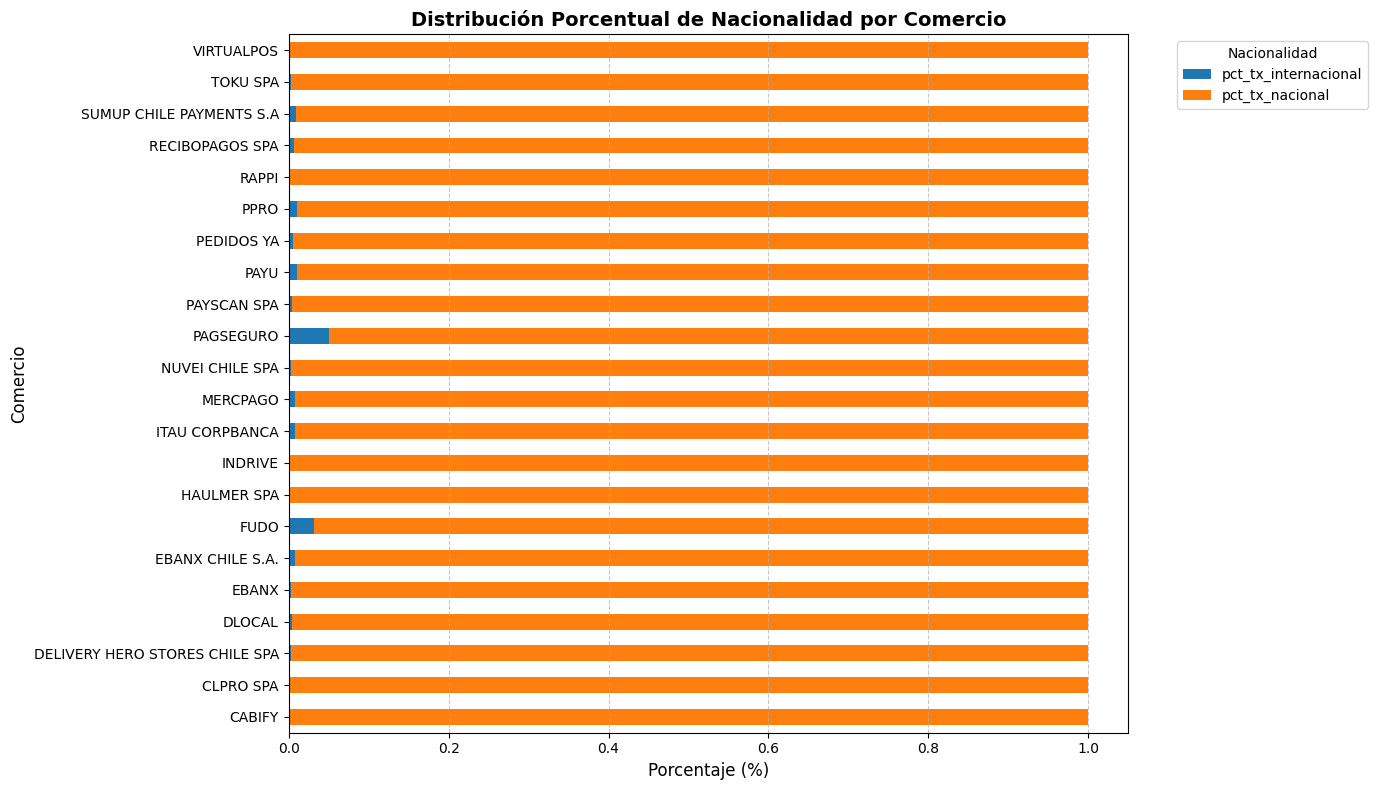

In [66]:
# Obtener el tipo de dato de la columna nacionalidad
print(f"Tipo de dato de la columna 'nacionalidad': {df['nacionalidad'].dtype}")

# Obtener los valores únicos de nacionalidad
print(f"Cantidad de nacionalidades únicas: {len(df['nacionalidad'].unique())}")
print(f"{df['nacionalidad'].unique()}")

# Distribución de la columna nacionalidad por transacciones
# Filas=Comercio, Columnas=Nacionalidad, Valores=Suma de Cantidad de Tx
df_nac_mix = df.pivot_table(
    index='nombre_comercio', # Filas
    columns='nacionalidad', # Columnas
    values='cantidad_tx', # Valores a agregar
    aggfunc='sum', # Función de agregación
    fill_value=0
)

# Calcular el porcentaje
df_nac_pct = df_nac_mix.div(df_nac_mix.sum(axis=1), axis=0)

# Renombrar columnas para formato amigable
# Limpiamos los nombres
df_nac_pct.columns = [f'pct_tx_{str(col).lower().strip().replace(" ", "_")}' for col in df_nac_pct.columns]

# Visualizar
fig, ax = plt.subplots(figsize=(14, 8))
df_nac_pct.plot(kind='barh', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Distribución Porcentual de Nacionalidad por Comercio', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje (%)', fontsize=12)
ax.set_ylabel('Comercio', fontsize=12)
ax.legend(title='Nacionalidad', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()  

### categoria_producto

Tipo de dato de la columna 'categoria_producto': object
Cantidad de categorías de producto únicas: 3
['PREPAGO' 'CREDITO' 'DEBITO']


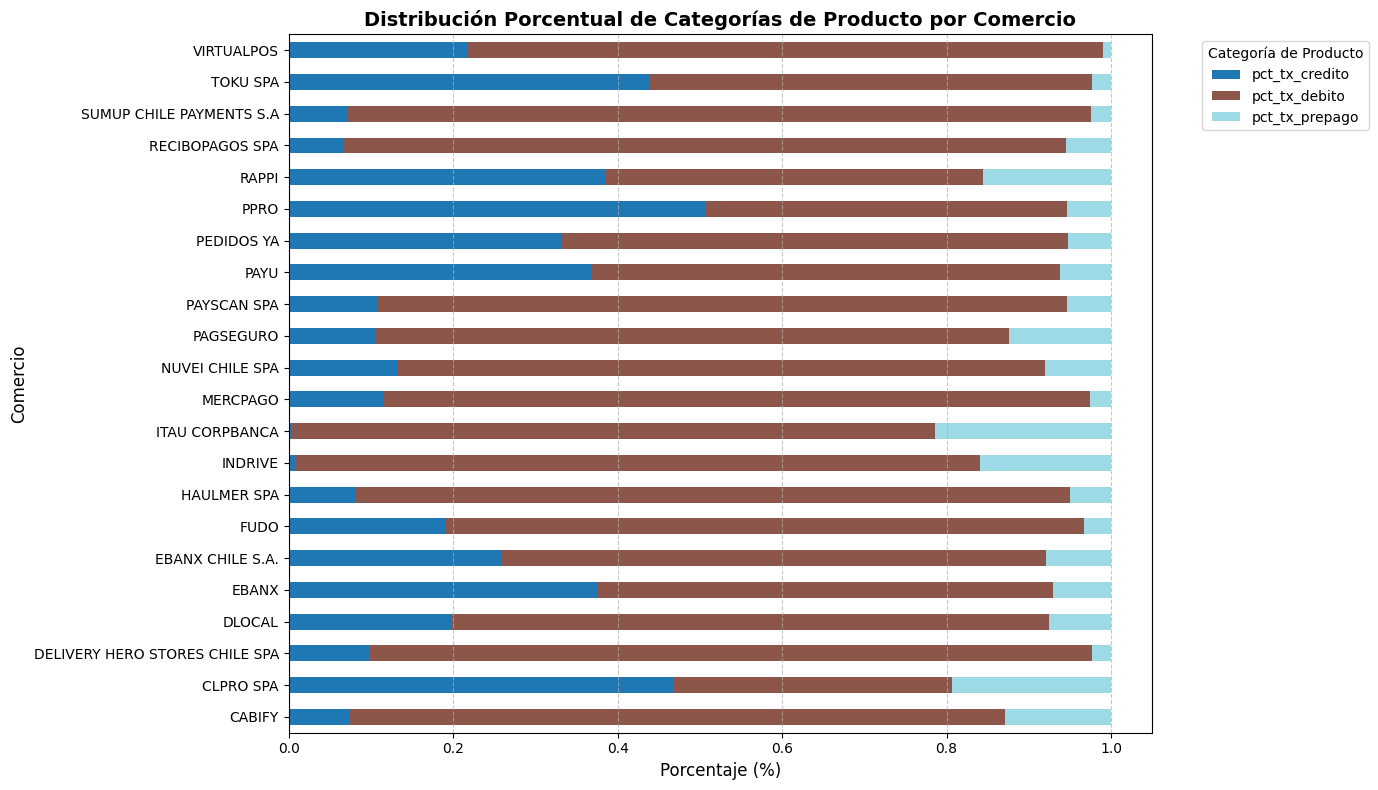

In [67]:
# Obtener el tipo de dato de la columna categoria_producto
print(f"Tipo de dato de la columna 'categoria_producto': {df['categoria_producto'].dtype}")

# Obtener los valores únicos de categoria_producto
print(f"Cantidad de categorías de producto únicas: {len(df['categoria_producto'].unique())}")
print(f"{df['categoria_producto'].unique()}")

# Distribución de la columna categoria_producto por transacciones
df_catprod_mix = df.pivot_table(
    index='nombre_comercio', 
    columns='categoria_producto', 
    values='cantidad_tx', 
    aggfunc='sum', 
    fill_value=0
)

# Calcular el porcentaje
df_catprod_pct = df_catprod_mix.div(df_catprod_mix.sum(axis=1), axis=0)

# Renombrar columnas para formato amigable
df_catprod_pct.columns = [f'pct_tx_{str(col).lower().strip().replace(" ", "_")}' for col in df_catprod_pct.columns]

# Visualizar
fig, ax = plt.subplots(figsize=(14, 8))
df_catprod_pct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Distribución Porcentual de Categorías de Producto por Comercio',  fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje (%)', fontsize=12)
ax.set_ylabel('Comercio', fontsize=12)
ax.legend(title='Categoría de Producto', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### tarjeta_presente

Tipo de dato de la columna tarjeta_presente: object
Cantidad de valores únicos en tarjeta_presente: 2
['No' 'Si']


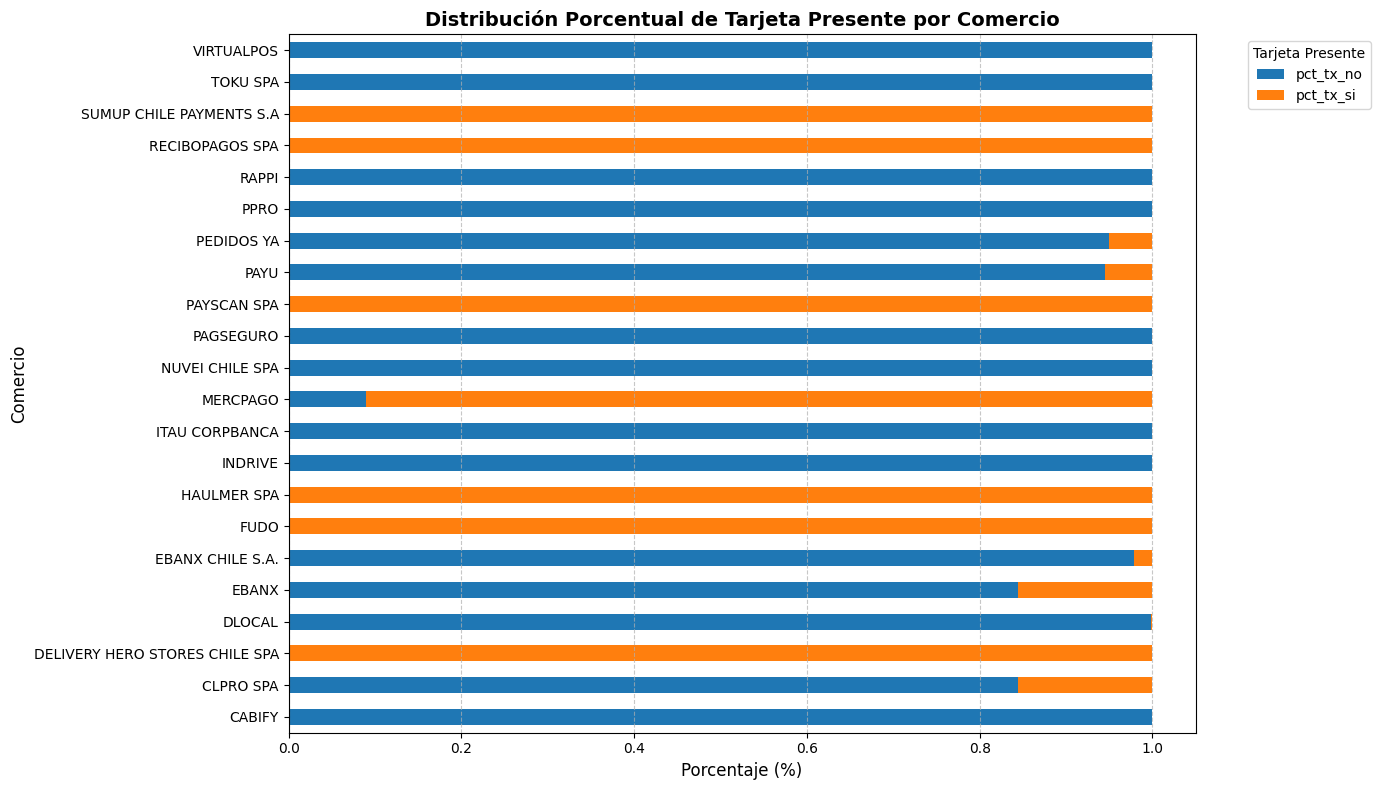

In [68]:
# Obtener el tipo de dato de la columna tarjeta_presente
print(f"Tipo de dato de la columna tarjeta_presente: {df['tarjeta_presente'].dtype}")

# Obtener los valores únicos de tarjeta_presente
print(f"Cantidad de valores únicos en tarjeta_presente: {len(df['tarjeta_presente'].unique())}")
print(f"{df['tarjeta_presente'].unique()}")

# Distribución de la columna tarjeta_presente por transacciones
df_tarjpres_mix = df.pivot_table(
    index='nombre_comercio', 
    columns='tarjeta_presente', 
    values='cantidad_tx', 
    aggfunc='sum', 
    fill_value=0
)

# Calcular el porcentaje
df_tarjpres_pct = df_tarjpres_mix.div(df_tarjpres_mix.sum(axis=1), axis=0)

# Renombrar columnas para formato amigable
df_tarjpres_pct.columns = [f'pct_tx_{str(col).lower().strip().replace(" ", "_")}' for col in df_tarjpres_pct.columns]

# Visualizar
fig, ax = plt.subplots(figsize=(14, 8))
df_tarjpres_pct.plot(kind='barh', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Distribución Porcentual de Tarjeta Presente por Comercio', fontsize=14, fontweight='bold')   
ax.set_xlabel('Porcentaje (%)', fontsize=12)
ax.set_ylabel('Comercio', fontsize=12)
ax.legend(title='Tarjeta Presente', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### cantidad_tx

In [69]:
# Obtener el tipo de dato de la columna cantidad_tx
print(f"Tipo de dato de la columna cantidad_tx: {df['cantidad_tx'].dtype}")

# Obtener los valores únicos de cantidad_tx
print(f"Cantidad de valores únicos en cantidad_tx: {len(df['cantidad_tx'].unique())}")

# Rango de valores de cantidad_tx (para comprobar)
rango_cantidad_tx = (int(df['cantidad_tx'].min()), int(df['cantidad_tx'].max()))
print(f"Rango de valores en cantidad_tx: {rango_cantidad_tx}")

Tipo de dato de la columna cantidad_tx: int64
Cantidad de valores únicos en cantidad_tx: 34208
Rango de valores en cantidad_tx: (1, 361166)


### tpv

In [70]:
# Obtener el tipo de dato de la columna tpv
print(f"Tipo de dato de la columna tpv: {df['tpv'].dtype}")


# Rango de valores de tpv (para comprobar)
rango_tpv = (int(df['tpv'].min()), int(df['tpv'].max()))
print(f"Rango de valores en tpv: {rango_tpv}")

# Calcular el TPV Total por Comercio
df_share = df.groupby('nombre_comercio')['tpv'].sum().reset_index()

# Calcular el TPV Total del Sistema (La suma de todo)
tpv_gran_total = df_share['tpv'].sum()

# Calcular el Porcentaje de cada uno
df_share['pct_del_total'] = df_share['tpv'] / tpv_gran_total

# Ordenar para ver a los "Gigantes" primero
df_share = df_share.sort_values('pct_del_total', ascending=False)

# Calcular el porcentaje acumulado
df_share['pct_acumulado'] = df_share['pct_del_total'].cumsum()

# Formateo para ver mejor los números
# Multiplicamos por 100 para verlo como porcentaje legible (ej: 0.25 -> 25.0%)
df_share['pct_del_total_label'] = (df_share['pct_del_total'] * 100).map('{:,.2f}%'.format)

# Visualizar Top 10 comercios que más pesan en tu cartera
print(f"TPV Total: ${tpv_gran_total:,.0f}")
df_share[['nombre_comercio', 'tpv', 'pct_del_total_label']]

Tipo de dato de la columna tpv: float64
Rango de valores en tpv: (5, 2312763882)
TPV Total: $19,894,349,060,870


,nombre_comercio,tpv,pct_del_total_label
10,MERCPAGO,7.945322e+12,39.94%
3,DLOCAL,3.644495e+12,18.32%
14,PAYU,3.465763e+12,17.42%
19,SUMUP CHILE PAYMENTS S.A,1.370809e+12,6.89%
15,PEDIDOS YA,1.213673e+12,6.10%
5,EBANX CHILE S.A.,8.997327e+11,4.52%
20,TOKU SPA,5.177424e+11,2.60%
7,HAULMER SPA,3.916768e+11,1.97%
17,RAPPI,1.010262e+11,0.51%
6,FUDO,8.242523e+10,0.41%


### Guardado del dataset inicial limpio

In [71]:
RUTA_CARPETA_DATA = Path('../data')
NOMBRE_ARCHIVO = 'dataset_inicial_limpio.parquet'
RUTA_COMPLETA = RUTA_CARPETA_DATA / NOMBRE_ARCHIVO

# Guardar el DataFrame limpio en formato Parquet
try:
    df.to_parquet(RUTA_COMPLETA, index=False)
    print(f"Dataset limpio guardado exitosamente en: {RUTA_COMPLETA}")
except Exception as e:
    print(f"Ocurrió un error al guardar el archivo: {e}")

Dataset limpio guardado exitosamente en: ..\data\dataset_inicial_limpio.parquet
